In [1]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, AnyMessage, ToolMessage
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen/qwen3-32b")
llm.invoke("test line")

AIMessage(content='<think>\nOkay, the user wrote "test line". That\'s pretty short. I need to figure out what they want. Maybe they\'re just checking if the system is working. They might be testing if I respond correctly to simple inputs. Let me see. Since there\'s no specific question or task, I should probably ask them how I can assist further. Keep it friendly and open-ended. Let me make sure my response is helpful and encourages them to provide more details if needed.\n</think>\n\nHello! It seems like you\'re testing the line. How can I assist you today? Feel free to ask any questions or let me know if there\'s something specific you\'d like help with! 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 10, 'total_tokens': 151, 'completion_time': 0.346926158, 'prompt_time': 0.000460874, 'queue_time': 0.049894087, 'total_time': 0.347387032}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_8487b76fd3', 'finish_reason': 'st

In [2]:
import operator
from typing import List
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph,START, END, MessagesState

In [31]:
def call_model(state: MessagesState):
    question = state['messages']
    
    response = llm.invoke(question)
    
    return {
        "messages": [response]
    }

In [27]:
state = {
    "messages": ["Assalamualikum sir."]
}
call_model(state)

{'messages': [AIMessage(content='<think>\nOkay, the user said "Assalamualikum sir." I need to respond appropriately. First, I should acknowledge their greeting. In Islamic tradition, the proper response is "Wa alaikum salam." But since they added "sir," maybe I should also include a respectful title. Let me check if that\'s common. Sometimes people add "wa rahmatullah" for extra politeness. Also, the user might be looking for a friendly and welcoming reply. I should make sure to be warm and offer assistance. Let me structure the response: start with the greeting reply, add a thank you, and ask how I can help. Keep it concise but friendly. Alright, that should cover it.\n</think>\n\nWa alaikum salam wa rahmatullahi wa barakatuh! (Peace and blessings of Allah be upon you!) \n\nThank you for reaching out. How can I assist you today? May Allah guide us all towards knowledge and goodness. 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 204, 'prompt_tokens':

## Build The Graph

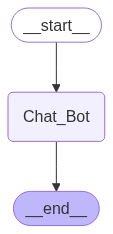

In [32]:
workflow = StateGraph(MessagesState)

workflow.add_node("Chat_Bot", call_model)

workflow.add_edge(START, "Chat_Bot")
workflow.add_edge("Chat_Bot", END)

graph = workflow.compile()

from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
output = graph.invoke(
    {
        "messages":["Hello sir"]
    }
)

for m in output['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello sir
================================== Ai Message ==================================

<think>
Okay, the user just said "Hello sir". Let me start by acknowledging their greeting. I should respond in a friendly and open manner to encourage them to ask questions or share what's on their mind. Maybe something like, "Hello! How can I assist you today?" That's polite and invites them to elaborate. I need to make sure my response is welcoming and not too formal. Let me check if there's anything else I should consider. The user might be starting a conversation, so keeping it simple and approachable is key. Alright, that should work.
</think>

Hello! How can I assist you today? 😊


In [38]:

output = graph.invoke(
    {
        "messages":["i'm good, how are you?"]
    }
)

for m in output['messages']:
    m.pretty_print()

================================ Human Message =================================

i'm good, how are you?
================================== Ai Message ==================================

<think>
Okay, the user asked how I am. Since I don't have feelings, I need to be clear about that. I should respond in a friendly and helpful way. Maybe say something like I'm functioning well and ask if they need help with anything. Keep the tone positive and approachable. Make sure not to overcomplicate things. Just a simple, honest reply.
</think>

I'm functioning well, thanks for asking! I'm here to help if you need anything—whether it's questions, ideas, or just someone to chat with. How can I assist you today? 😊
